In [44]:
%matplotlib inline
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('archive/amz_uk_price_prediction_dataset.csv')


Preliminary Step: Remove outliers in product prices.

For this purpose, we can use the IQR (Interquartile Range) method. Products priced below the first quartile minus 1.5 times the IQR or above the third quartile plus 1.5 times the IQR will be considered outliers and removed from the dataset. The next steps will be done with the dataframe without outliers.

Hint: you can check the last Check For Understanding at the end of the lesson EDA Bivariate Analysis for a hint on how to do this.

In [47]:
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

df_no_outliers = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

Violin Plots:

Use a violin plot to visualize the distribution of price across different product categories. Filter out the top 20 categories based on count for better visualization.
Which product category tends to have the highest median price? Don't filter here by top categories.

In [81]:
crosstab_df = pd.crosstab(df['category'], df['isBestSeller'])
print(crosstab_df.head(10))



isBestSeller                       False  True 
category                                       
3D Printers                          247      1
3D Printing & Scanning              4065      2
Abrasive & Finishing Products        245      5
Action Cameras                      1696      1
Adapters                             251      3
Agricultural Equipment & Supplies   8421    109
Alexa Built-In Devices               106      1
Art & Craft Supplies                 253      5
Arts & Crafts                       9319    230
Baby                               14709    341


## Are there categories where being a best-seller is more prevalent?

In [50]:
proportions = crosstab_df.div(crosstab_df.sum(axis=1), axis=0)
best_seller_trends = proportions[True].sort_values(ascending=False)
# print(best_seller_trends.head(10))
# if best_seller_trends.values >= 0.05:
#     print("")

top_categories = best_seller_trends[best_seller_trends >= 0.05]
print(top_categories)

category
Grocery                           0.058135
Smart Home Security & Lighting    0.057692
Health & Personal Care            0.057686
Name: True, dtype: float64


## Statistical Tests:

## Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.

In [51]:
from scipy.stats import chi2_contingency
import numpy as np

chi2, p, dof, ex = chi2_contingency(crosstab_df)


In [52]:
total_products = crosstab_df.sum().sum()
number_of_options = min(crosstab_df.shape) - 1
v_score = np.sqrt(chi2 / (total_products * number_of_options))

print(f"is random? (P-value): {p}") 
print(f"how strong does CATEGORY affect best-seller status? (0-1 scale): {v_score}")

is random? (P-value): 0.0
how strong does CATEGORY affect best-seller status? (0-1 scale): 0.1222829439760564


## Compute Cramér's V to understand the strength of association between best-seller status and category.

In [53]:
top_10_categories = df['category'].value_counts().nlargest(10).index
plot_data = proportions.loc[top_10_categories]

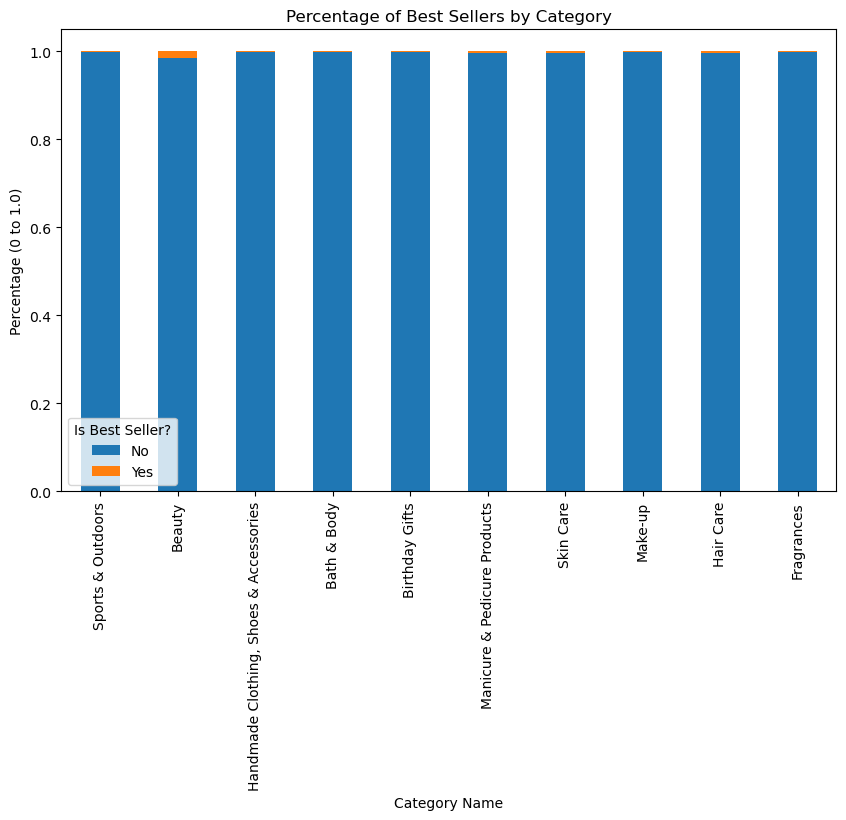

In [38]:
plot_data.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.title('Percentage of Best Sellers by Category')
plt.xlabel('Category Name')
plt.ylabel('Percentage (0 to 1.0)')
plt.legend(title='Is Best Seller?', labels=['No', 'Yes'])
plt.show()

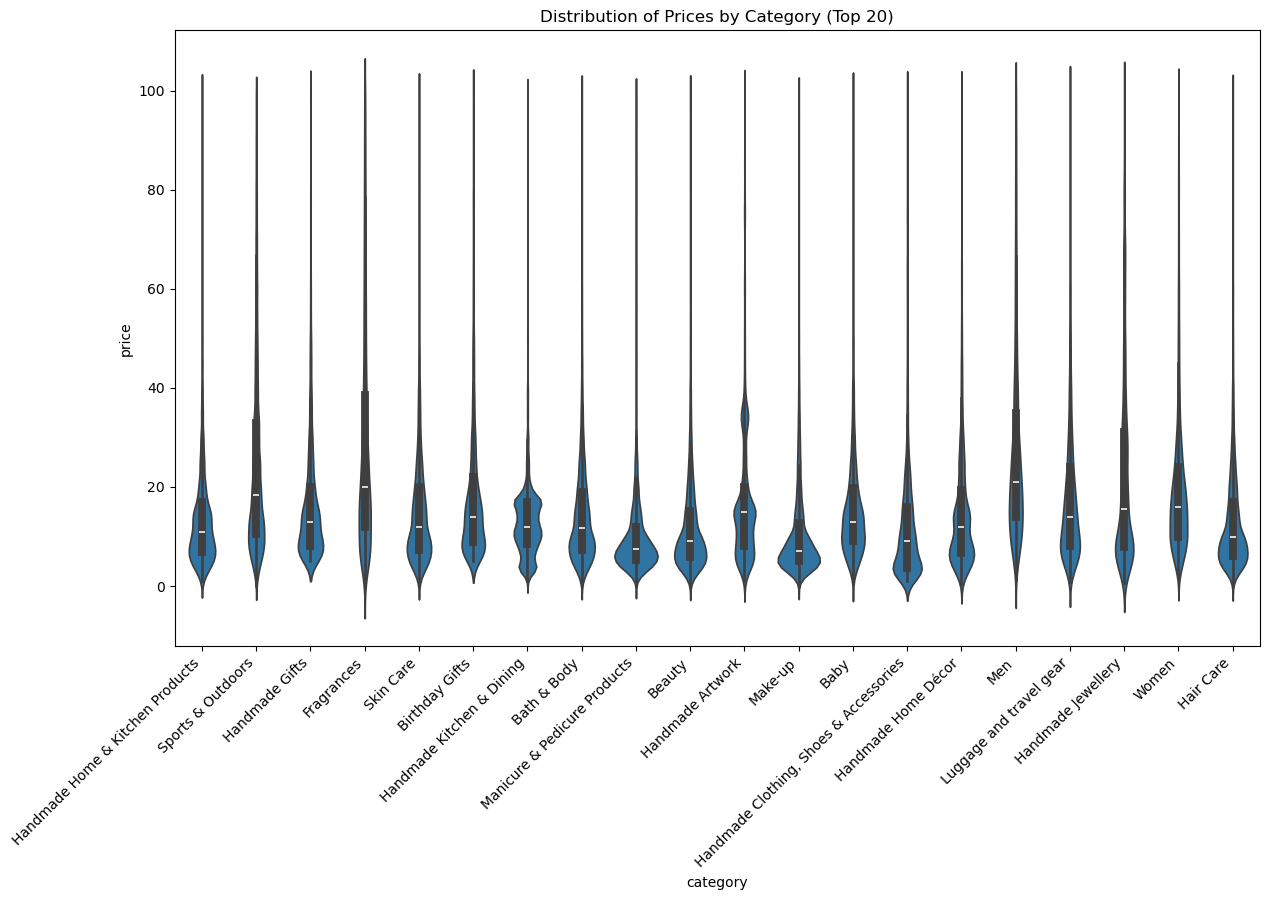

In [58]:
top_20_categories = df_no_outliers['category'].value_counts().nlargest(20).index
filtered_data_violin = df_no_outliers[df_no_outliers['category'].isin(top_20_categories)]

plt.figure(figsize=(14, 8))
sns.violinplot(x='category', y='price', data=filtered_data_violin)

plt.title('Distribution of Prices by Category (Top 20)')
plt.xticks(rotation=45, ha='right')
plt.show()

## Which product category tends to have the highest median price? Don't filter here by top categories.

In [64]:
median_prices = df_no_outliers.groupby('category')['price'].median().sort_values(ascending=False)
expensive_cat = median_prices.idxmax()
median_value = median_prices.max()
print(f"The most expensive category is '{expensive_cat}' with a median price of {median_value:.2f}.")
# plt.show()

The most expensive category is 'Desktop PCs' with a median price of 74.00.


## Bar chart comparing average price in top 10 categories

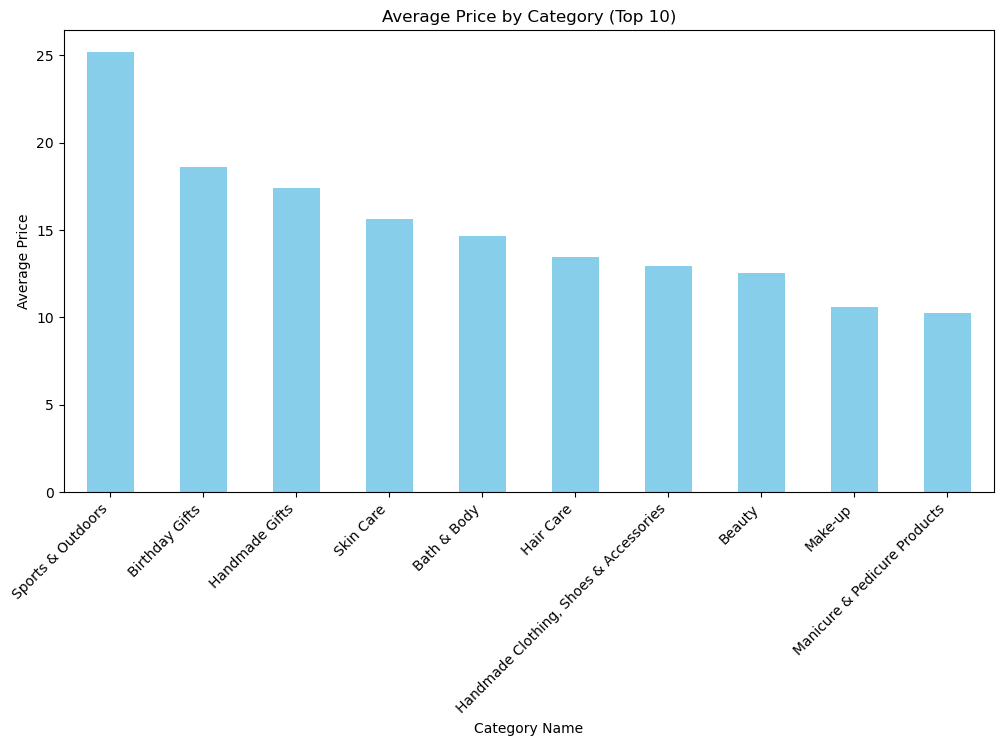

In [67]:
avg_prices = df_no_outliers.groupby('category')['price'].mean()

top_10_categories = df_no_outliers['category'].value_counts().nlargest(10).index
avg_prices_top_10 = avg_prices.loc[top_10_categories].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
avg_prices_top_10.plot(kind='bar', color='skyblue')
plt.title('Average Price by Category (Top 10)')
plt.xlabel('Category Name')
plt.ylabel('Average Price')
plt.xticks(rotation=45, ha='right') 
plt.show()

## Boxplots of ratings by category (top 10 categories)

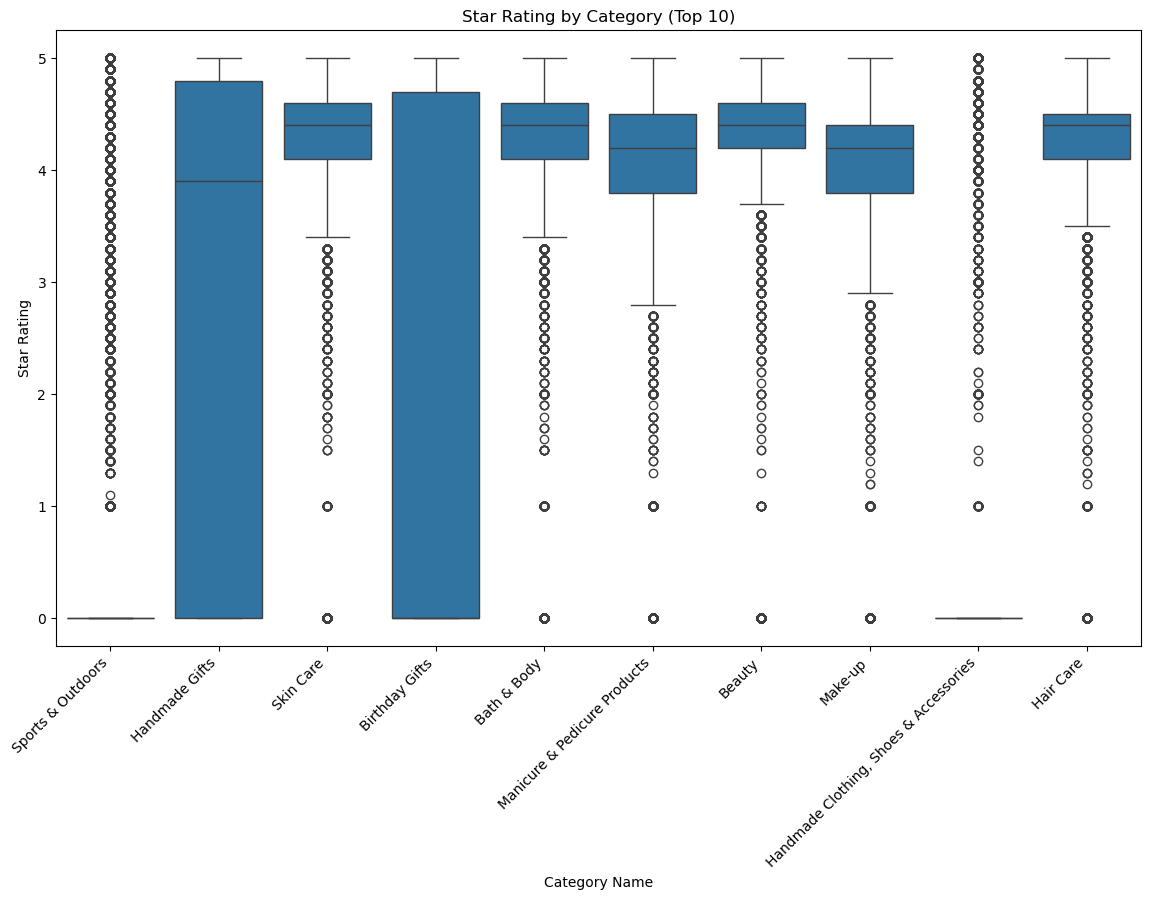

highest median star rating category: 'Computer Memory' with a median rating of 4.7.


In [76]:
top_10_volume = df_no_outliers['category'].value_counts().nlargest(10).index
df_top_10_stars = df_no_outliers[df_no_outliers['category'].isin(top_10_volume)]
plt.figure(figsize=(14, 8))
sns.boxplot(x='category', y='stars', data=df_top_10_stars)
plt.title('Star Rating by Category (Top 10)')
plt.xlabel('Category Name')
plt.ylabel('Star Rating')
plt.xticks(rotation=45, ha='right')
plt.show()

median_stars = df_no_outliers.groupby('category')['stars'].median().sort_values(ascending=False)
highest_median_stars_cat = median_stars.idxmax()
highest_median_stars_value = median_stars.max()

print (f"highest median star rating category: '{highest_median_stars_cat}' with a median rating of {highest_median_stars_value:.1f}.")   

## Part 3.1: Correlation coefficient between price and reviews"
Agora vamos mudar de foco: em vez de comparar categorias, vamos ver se o Preço influencia o Número de Reviews.

In [78]:
pearson_corr = df_no_outliers['price'].corr(df_no_outliers['reviews'])
spearman_corr = df_no_outliers['price'].corr(df_no_outliers['reviews'], method='spearman')

print(f"Pearson Correlation: {pearson_corr:.4f}")
print(f"Spearman Correlation: {spearman_corr:.4f}")

if abs(spearman_corr) < 0.1:
    conclusion = "no significant correlation."
else:
    conclusion = "some correlation, but it is likely weak."

print(f"\nConclusion: {conclusion}")

Pearson Correlation: -0.0085
Spearman Correlation: -0.0781

Conclusion: no significant correlation.


## Part 3.2: Scatter plot of price vs. rating, correlation heatmap, and QQ plot of prices

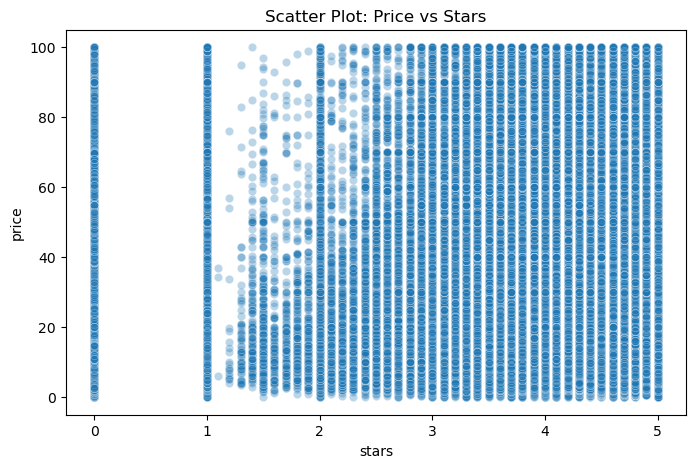

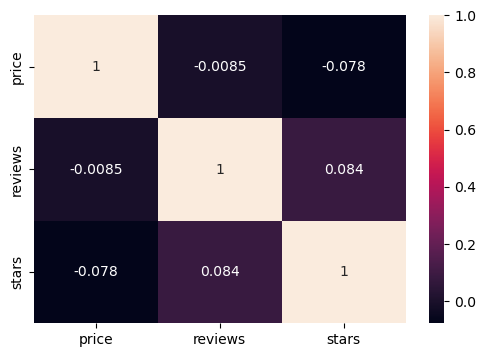

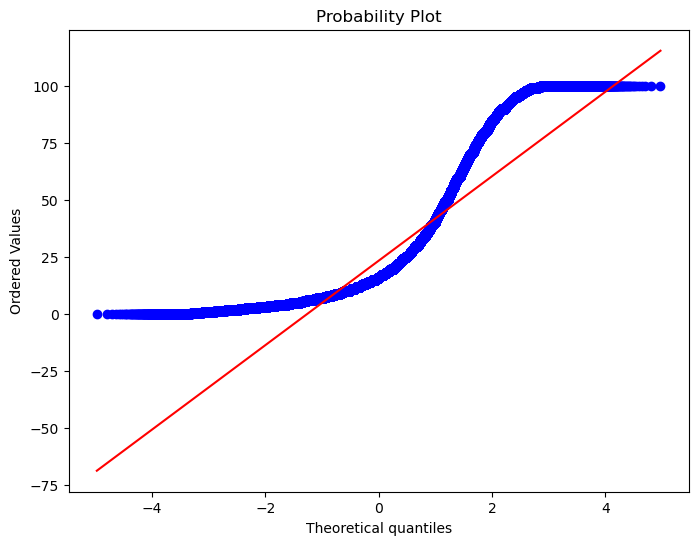

In [79]:
import scipy.stats as stats

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_no_outliers, x='stars', y='price', alpha=0.3)
plt.title('Scatter Plot: Price vs Stars')
plt.show()


plt.figure(figsize=(6, 4))
sns.heatmap(df_no_outliers[['price', 'reviews', 'stars']].corr(), annot=True)
plt.show()


plt.figure(figsize=(8, 6))
stats.probplot(df_no_outliers['price'], dist="norm", plot=plt)
plt.show()

## visualize the relationship between product categories and the best-seller status using a stacked bar chart.

In [ ]:
top_10_index = df['category'].value_counts().nlargest(10).index
plot_data = proportions.loc[top_10_index]

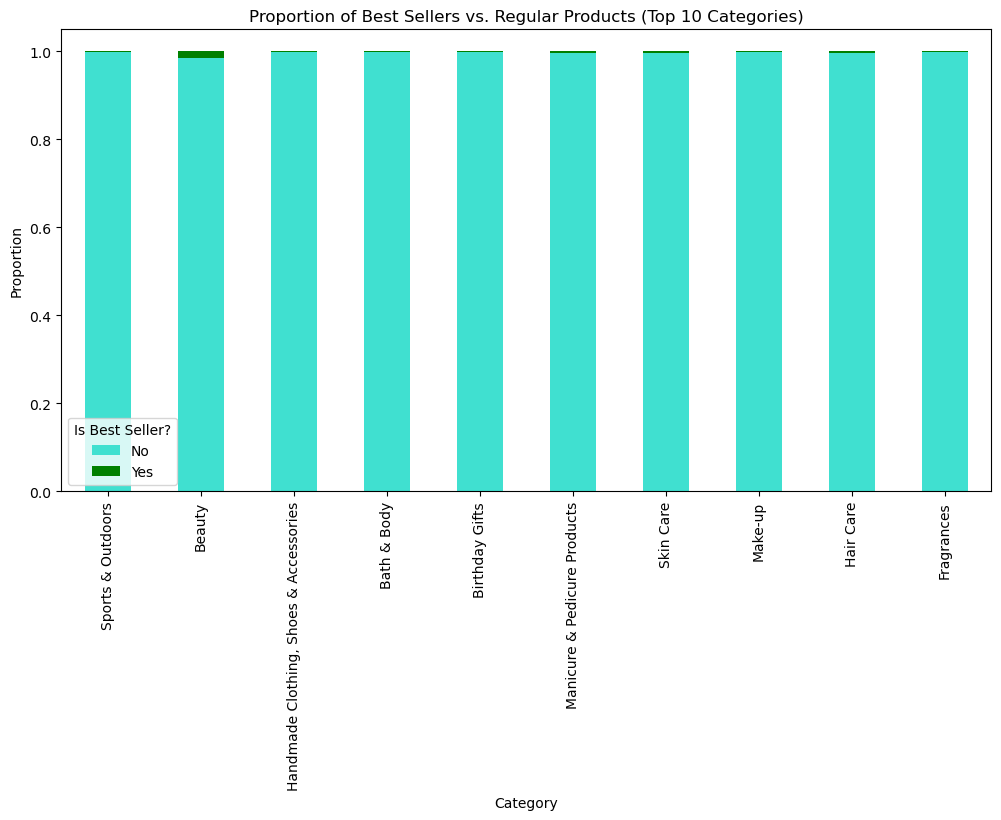

In [40]:
plot_data.plot(kind='bar', stacked=True, figsize=(12, 6), color=['turquoise', 'green'])

plt.title('Proportion of Best Sellers vs. Regular Products (Top 10 Categories)')
plt.xlabel('Category')
plt.ylabel('Proportion')
plt.legend(title='Is Best Seller?', labels=['No', 'Yes'])
plt.show()

## Business-centric Report: Amazon UK Insights

### 1. Best-Seller Trends
- **Finding**: The data shows that some categories definitely have more best-sellers than others. My statistical test (Chi-square) confirmed this isn't just a coincidence.
- **Insight**: Even so, the "connection" between the category and being a top seller is actually pretty weak (Cramér’s V is around 0.12). It tells me that while the category matters a bit, there are probably much bigger factors—like the brand or the marketing—that really decide if a product becomes a best-seller.

### 2. Price and Ratings Analysis
- **Finding**: If we look at the middle of the price range (median), 'Desktop PCs' is the most expensive spot. But if we look at the average, 'Sports & Outdoors' takes the lead, likely because of a few very high-priced items.
- **Finding**: On the quality side, 'Computer Memory' is the winner with a 4.7-star rating.
- **Insight**: This shows that niche, technical categories often have much happier customers than the big, general categories. People buying memory or PC parts seem to be getting exactly what they expect.

### 3. Price vs. Popularity
- **Finding**: I checked if expensive products get more reviews, but the correlation is almost zero (-0.008). 
- **Finding**: Also, the QQ Plot shows that prices don't follow a "normal" or balanced distribution; they are quite skewed.
- **Insight**: This is a big takeaway: price doesn't drive engagement. People are just as likely to leave a review for a cheap gadget as they are for an expensive one. As a business, you can't just lower the price and expect "social proof" (reviews) to grow automatically.